In [1]:
import scipy.io as sio
import numpy as np
import pandas as pd
import torch

ll = sio.loadmat("/home/jinhanz/cs/concreteness/other/251004_vb_whole_screen_LL.mat")
ll_array = ll['LL'].squeeze()

TrialNamesC = sio.loadmat("/home/jinhanz/cs/concreteness/other/251004_vb_whole_screen_TrialNamesC.mat")
TrialNamesC = TrialNamesC['TrialNamesC']
is_concrete = np.empty(TrialNamesC.shape[0], dtype=bool)

for i in range(TrialNamesC.shape[0]):
    for j in range(TrialNamesC.shape[1]):
        try:
            is_concrete[i] = "_con_" in TrialNamesC[i, j].item()[0]
        except:
            # is_concrete[i, j] = False
            print([i, j, TrialNamesC[i, j]])

[63, 6, array([], shape=(1, 0), dtype=float64)]
[69, 26, array([], shape=(1, 0), dtype=float64)]
[157, 24, array([], shape=(1, 0), dtype=float64)]


In [2]:
ll_array.shape, is_concrete.shape

((29, 160, 2), (160,))

In [2]:
LL1_con = np.nansum(ll_array[:,is_concrete,0], axis=1)
LL2_con = np.nansum(ll_array[:,is_concrete,1], axis=1)
AB_con = (LL1_con - LL2_con) / (np.abs(LL1_con) + np.abs(LL2_con))

LL1_abs = np.nansum(ll_array[:,~is_concrete,0], axis=1)
LL2_abs = np.nansum(ll_array[:,~is_concrete,1], axis=1)
AB_abs = (LL1_abs - LL2_abs) / (np.abs(LL1_abs) + np.abs(LL2_abs))

In [3]:
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(AB_con, AB_abs)
print(f"Paired t-test results: t-statistic = {t_stat}, p-value = {p_value}")

Paired t-test results: t-statistic = 4.069617405709671, p-value = 0.00034855878612896396


/tmp/ipykernel_1484757/4164919579.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.pointplot(data=df, x='Condition', y='AB_scale', ci=68, join=False,
/tmp/ipykernel_1484757/4164919579.py:18: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=df, x='Condition', y='AB_scale', ci=68, join=False,
/tmp/ipykernel_1484757/4164919579.py:18: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.pointplot(data=df, x='Condition', y='AB_scale', ci=68, join=False,


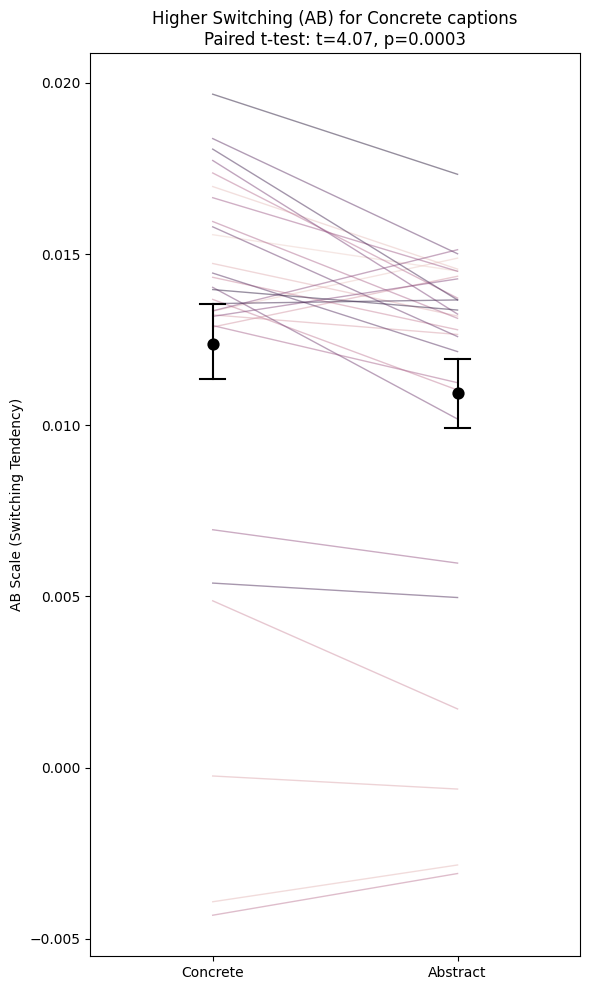

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting
df = pd.DataFrame({
    'Participant': range(len(AB_con)),
    'Concrete': AB_con,
    'Abstract': AB_abs
}).melt(id_vars='Participant', var_name='Condition', value_name='AB_scale')

# Paired line plot
plt.figure(figsize=(6, 10))
sns.lineplot(data=df, x='Condition', y='AB_scale', hue='Participant',
             estimator=None, lw=1, alpha=0.5, legend=False, color='gray')

# Overlay mean ± SE
sns.pointplot(data=df, x='Condition', y='AB_scale', ci=68, join=False,
              color='black', markers='o', capsize=.1, errwidth=1.5)

plt.title(f"Higher Switching (AB) for Concrete captions\nPaired t-test: t={t_stat:.2f}, p={p_value:.4f}")
plt.ylabel("AB Scale (Switching Tendency)")
plt.xlabel("")
plt.tight_layout()
plt.show()

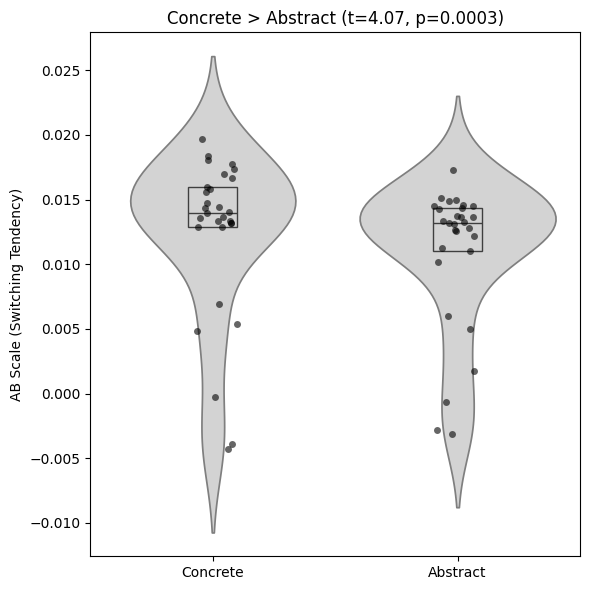

In [7]:
plt.figure(figsize=(6, 6))
sns.violinplot(data=df, x='Condition', y='AB_scale', inner=None, color='lightgray')
sns.boxplot(data=df, x='Condition', y='AB_scale', width=0.2, showcaps=False,
            boxprops={'facecolor':'none'}, showfliers=False, whiskerprops={'linewidth':0})
sns.stripplot(data=df, x='Condition', y='AB_scale', size=5, color='black', alpha=0.6)

plt.title(f"Concrete > Abstract (t={t_stat:.2f}, p={p_value:.4f})")
plt.ylabel("AB Scale (Switching Tendency)")
plt.xlabel("")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1484757/3015748606.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Condition', y='AB_scale',


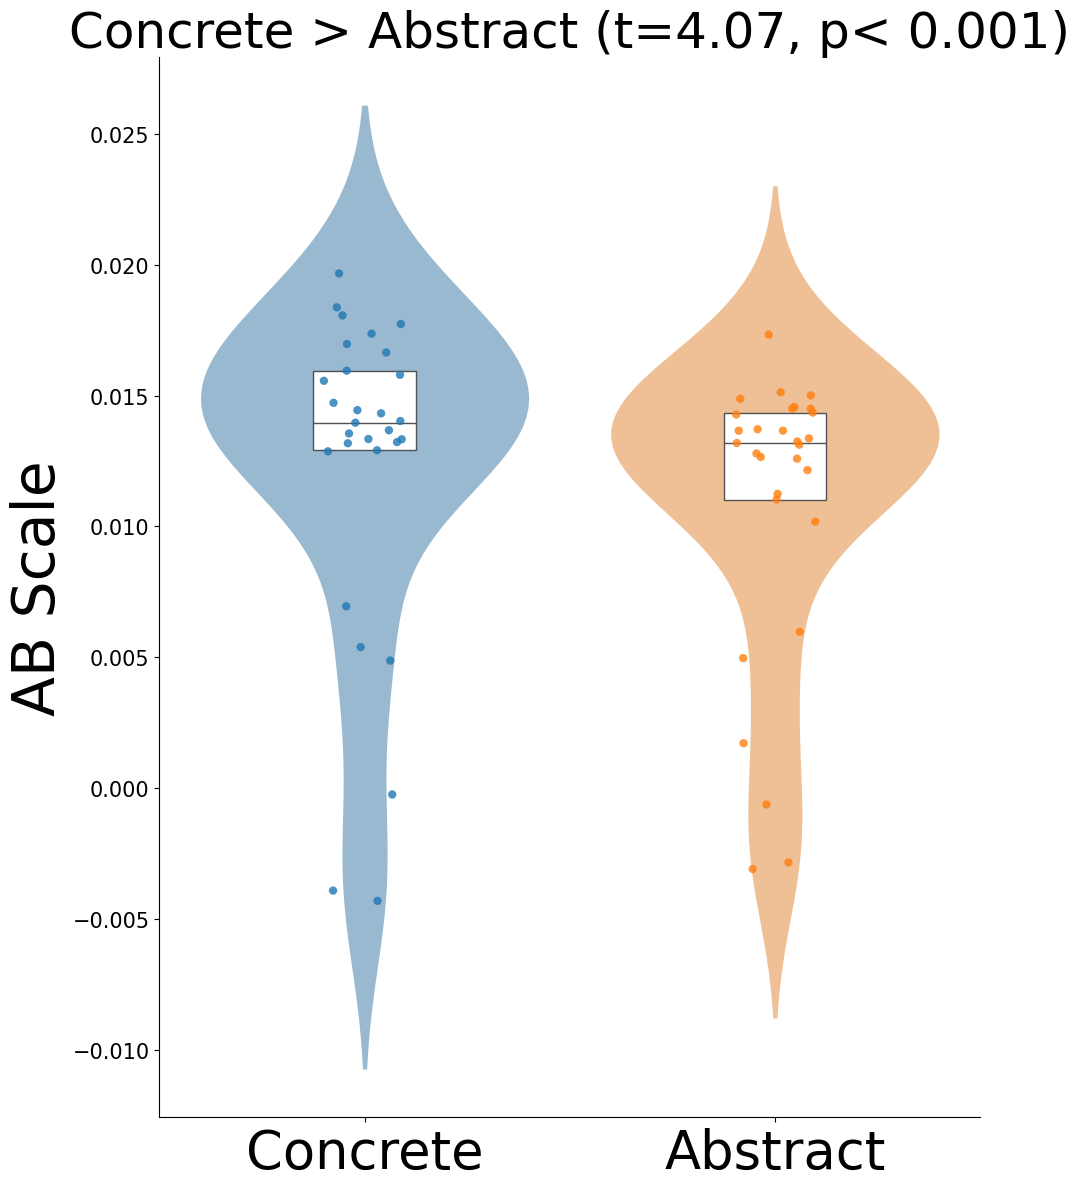

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Prepare data
df = pd.DataFrame({
    'Participant': range(len(AB_con)),
    'Concrete': AB_con,
    'Abstract': AB_abs
}).melt(id_vars='Participant', var_name='Condition', value_name='AB_scale')

# Choose colors (you can tweak these)
palette = {"Abstract": "tab:orange", "Concrete": "tab:blue"}  # blue vs orange

plt.figure(figsize=(10, 12))

# Violin plot (distribution)
sns.violinplot(data=df, x='Condition', y='AB_scale',
               inner=None, linewidth=0, palette=palette, alpha=0.5)

# Boxplot overlay (median + IQR)
sns.boxplot(data=df, x='Condition', y='AB_scale', width=0.25,
            showcaps=False, boxprops={'facecolor':'white', 'zorder':3},
            showfliers=False, whiskerprops={'linewidth':0}, zorder=3)

# Jittered individual points
sns.stripplot(data=df, x='Condition', y='AB_scale', hue='Condition',
              palette=palette, dodge=False, alpha=0.8, size=6, jitter=0.1, zorder=4)

# Clean up legend (duplicate hue)
plt.legend([],[], frameon=False)

# Significance annotation
y_max = df['AB_scale'].max()
y_sig = y_max + 0.05 * (df['AB_scale'].max() - df['AB_scale'].min())

# Labels & title
plt.title(f"Concrete > Abstract (t={t_stat:.2f}, p< 0.001)", fontsize=36)
plt.xticks(fontsize=38)  # Adjust the font size as needed
plt.yticks(fontsize=15)  # Adjust the font size as needed
plt.xlabel('')
plt.ylabel("AB Scale", fontsize=42)
sns.despine()
plt.tight_layout()
plt.show()